In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/home/adrieto/.virtualenvs/dataScience/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


In [3]:
posts = pd.read_csv("posts_categorias.csv", parse_dates=["fecha_publicacion"])
posts_original = posts.copy()
posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_post            5000 non-null   int64         
 1   fecha_publicacion  5000 non-null   datetime64[ns]
 2   hora               5000 non-null   int64         
 3   categoria          5000 non-null   object        
 4   impresiones        5000 non-null   int64         
 5   vistas             5000 non-null   int64         
 6   likes              5000 non-null   int64         
 7   comentarios        5000 non-null   int64         
 8   shares             5000 non-null   int64         
 9   longitud           5000 non-null   int64         
dtypes: datetime64[ns](1), int64(8), object(1)
memory usage: 390.8+ KB


In [4]:
posts.head()

,id_post,fecha_publicacion,hora,categoria,impresiones,vistas,likes,comentarios,shares,longitud
0,1,2026-07-26 16:54:35,16,tech,480,455,14,6,4,396
1,2,2026-06-18 09:13:51,9,tech,2098,1893,47,26,33,338
2,3,2026-04-26 15:13:19,15,tech,6930,5520,172,73,59,259
3,4,2026-05-08 08:20:41,8,tech,2847,2363,77,31,38,373
4,5,2026-06-12 12:05:15,12,business,1437,1109,17,10,6,173


In [5]:
# Calculo de distribucion de posts por categoria y por mes
posts["mes"] = (posts["fecha_publicacion"]).dt.month

posts_mes_categoria = (
    posts.groupby(["categoria", "mes"])
    .size()
    .reset_index(name="cantidad")
)

posts_mes_categoria.head()

,categoria,mes,cantidad
0,business,2,43
1,business,3,168
2,business,4,155
3,business,5,168
4,business,6,152


In [10]:
# Creamos una tabla pivot
df = posts_mes_categoria.pivot(
    index="mes",
    columns="categoria",
    values="cantidad"
)

# df.columns
df.head()

categoria,business,design,tech
mes,,,
2,43,68,110
3,168,275,435
4,155,271,430
5,168,279,434
6,152,235,413


<Figure size 640x480 with 0 Axes>

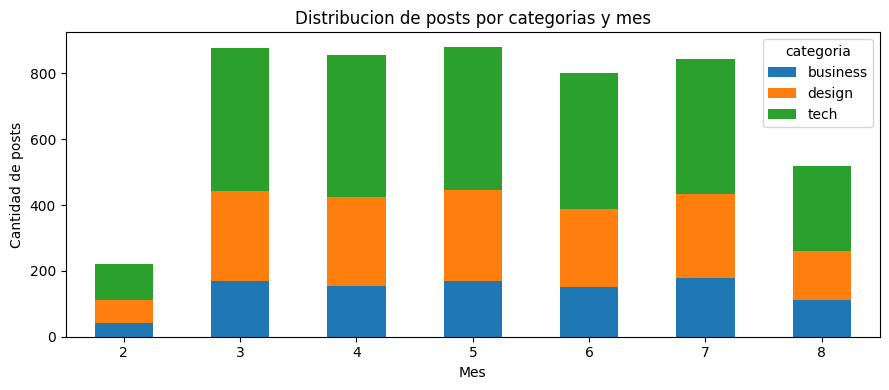

In [ ]:
plt.figure()
df.plot(kind="bar", stacked=True, figsize=(9,4))
plt.title("Distribucion de posts por categorias y mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de posts")
plt.xticks(rotation=0)
plt.tight_layout()
# plt.bar(posts_mes_categoria["mes"], posts_mes_categoria["cantidad"], bottom="categoria")

### Calculo de engagement promedio por categoria
Primero, agregamos tasas de engagement clasico y ponderado a cada post

$$
\text{Tasa de engagement(clásico)} =
\frac{\text{likes} + \text{shares} + \text{comentarios}}
{\text{vistas}} \times 100
$$

$$\text{Tasa de engagement ponderado (\%)} = \frac{\text{likes} + (\text{comentarios} \times 4) + (\text{shares} \times 8)}{\text{vistas}}\times 100$$



In [ ]:
engagement = ((posts["likes"] 
              + posts["shares"] 
              + posts["comentarios"]) / posts["vistas"] * 100).round(2)
engagement_ponderado = ((posts["likes"] 
                        + 8 * posts["shares"] 
                        + 4 * posts["comentarios"]) / posts["vistas"] * 100).round(2)

# Agregamos las columnas al DataFrame
posts["engagement"] = engagement
posts["engage_pond"] = engagement_ponderado

In [ ]:
posts.head()

,id_post,fecha_publicacion,hora,categoria,impresiones,vistas,likes,comentarios,shares,longitud,mes,engagement,engage_pond
0,1,2026-07-26 16:54:35,16,tech,480,455,14,6,4,396,7,5.27,15.38
1,2,2026-06-18 09:13:51,9,tech,2098,1893,47,26,33,338,6,5.60,21.92
2,3,2026-04-26 15:13:19,15,tech,6930,5520,172,73,59,259,4,5.51,16.96
3,4,2026-05-08 08:20:41,8,tech,2847,2363,77,31,38,373,5,6.18,21.37
4,5,2026-06-12 12:05:15,12,business,1437,1109,17,10,6,173,6,2.98,9.47


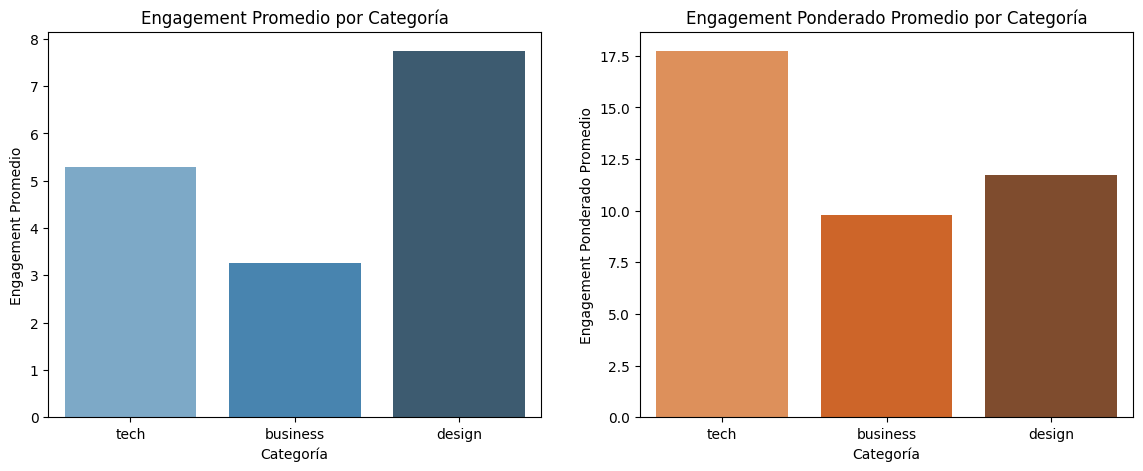

In [ ]:
# 1. Crear la figura y la grilla de subplots (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# 2. Primer gráfico: Engagement estándar en el subplot izquierdo (axes[0])
sns.barplot(
    data=posts,
    x='categoria',
    y='engagement',
    estimator='mean',  # Calcula el promedio automáticamente
    errorbar=None,
    palette='Blues_d',
    hue='categoria',
    legend=False,
    ax=axes[0],
)
axes[0].set_title('Engagement Promedio por Categoría')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Engagement Promedio')

# 3. Segundo gráfico: Engagement ponderado en el subplot derecho (axes[1])
sns.barplot(
    data=posts,
    x='categoria',
    y='engage_pond',
    estimator='mean',
    errorbar=None,
    palette='Oranges_d',
    hue='categoria',
    legend=False,
    ax=axes[1],
)
axes[1].set_title('Engagement Ponderado Promedio por Categoría')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Engagement Ponderado Promedio')

# 4. Ajustar espacio entre gráficos y mostrar
# plt.tight_layout()
plt.show()

### Relacion entre la longitud de los post y el engagement

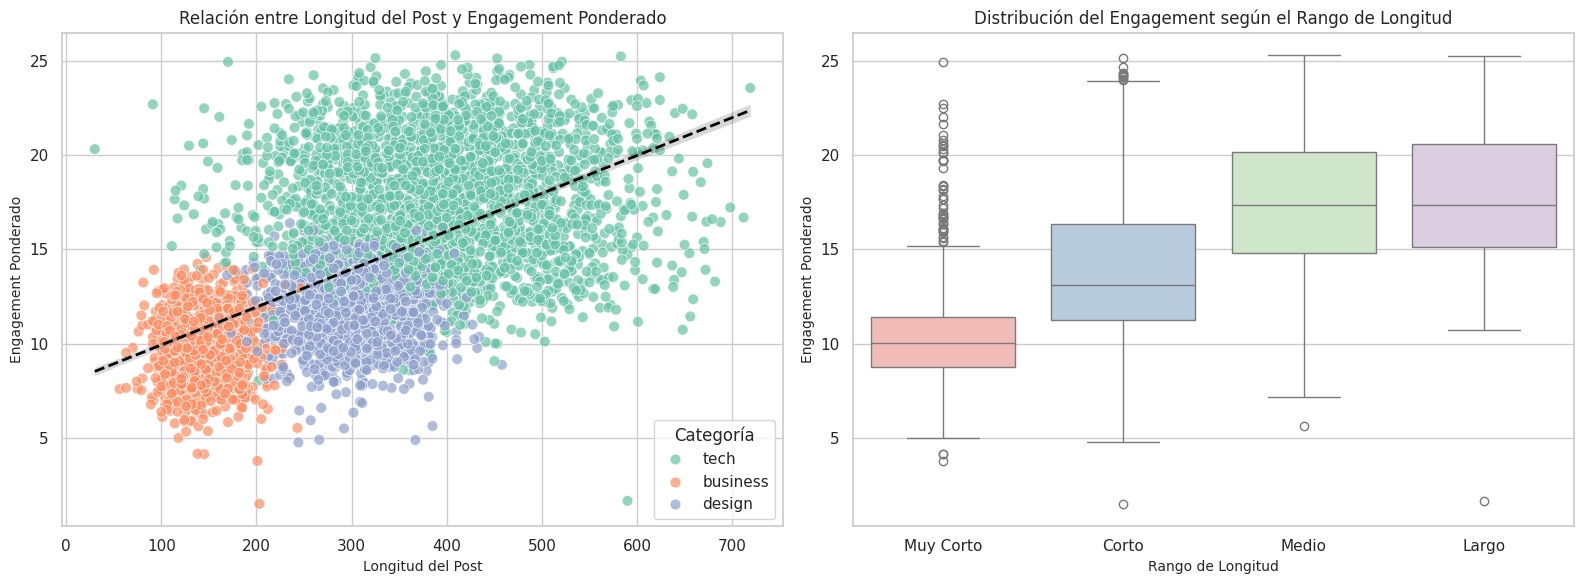

In [ ]:
# Configuración de estilo
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------
# SUBPLOT 1: Scatter Plot (Longitud vs Engage_Pond por Categoría)
# -------------------------------------------------------------------
sns.scatterplot(
    data=posts,
    x='longitud',
    y='engage_pond',
    hue='categoria',  # Separa por color según la categoría
    palette='Set2',
    alpha=0.7,
    s=60,
    ax=axes[0],
)

# Línea de tendencia general sobre el gráfico de dispersión
sns.regplot(
    data=posts,
    x='longitud',
    y='engage_pond',
    scatter=False,  # No redibujar los puntos
    ax=axes[0],
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 2, 'label': 'Tendencia general'},
)

axes[0].set_title(
    'Relación entre Longitud del Post y Engagement Ponderado', fontsize=12
)
axes[0].set_xlabel('Longitud del Post', fontsize=10)
axes[0].set_ylabel('Engagement Ponderado', fontsize=10)
axes[0].legend(title='Categoría')

# -------------------------------------------------------------------
# SUBPLOT 2: Boxplot por Rangos de Longitud
# -------------------------------------------------------------------
# 1. Agrupar la longitud en 4 rangos dentro del dataframe posts
posts['rango_longitud'] = pd.cut(
    posts['longitud'],
    bins=4,
    labels=['Muy Corto', 'Corto', 'Medio', 'Largo'],
)

# 2. Graficar el Boxplot
sns.boxplot(
    data=posts,
    x='rango_longitud',
    y='engage_pond',
    hue="rango_longitud",
    legend=False,
    palette='Pastel1',
    ax=axes[1],
)

axes[1].set_title(
    'Distribución del Engagement según el Rango de Longitud', fontsize=12
)
axes[1].set_xlabel('Rango de Longitud', fontsize=10)
axes[1].set_ylabel('Engagement Ponderado', fontsize=10)

# Ajustar espacio y mostrar
plt.tight_layout()
plt.show()

### Analisis del engagement respecto al horario de publicacion de los posts

In [ ]:
posts_hora_engage = (
    posts.groupby(["hora"])[
        ["engagement", "engage_pond"]
        ]
    .mean()
    # .reset_index(name="cantidad")
)

posts_hora_engage.head()

,engagement,engage_pond
hora,,
0,5.843585,14.585094
1,5.428182,14.083333
2,4.423750,13.429375
3,5.891071,13.651071
4,5.717419,15.309032


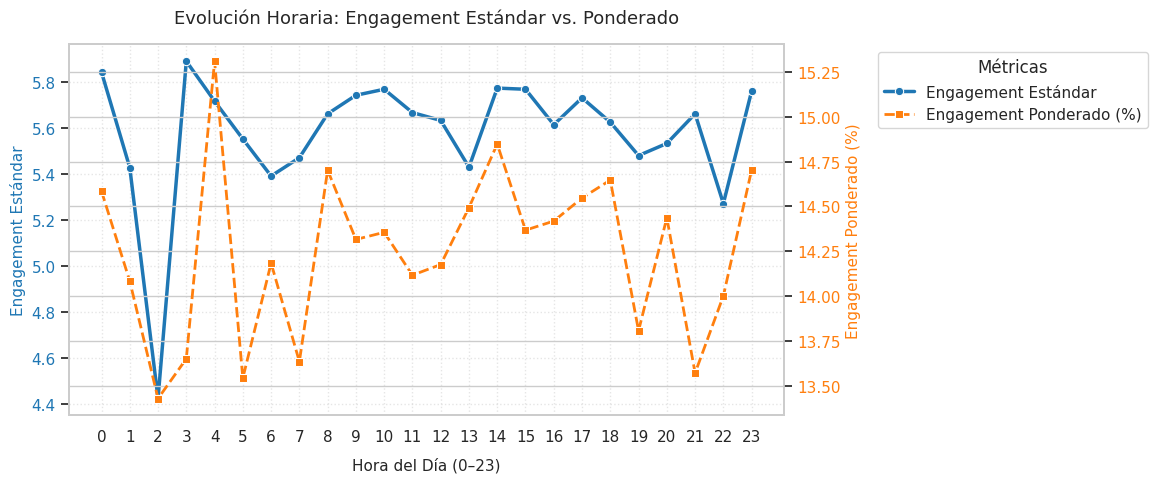

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# -------------------------------------------------------------------
# 1. Primera línea: Eje Y Izquierdo (Azul - Sólida)
# -------------------------------------------------------------------
sns.lineplot(
    data=posts_hora_engage,
    x='hora',
    y='engagement',
    color='#1f77b4',
    marker='o',
    linewidth=2.5,
    ax=ax1,
    label='Engagement Estándar',
)
ax1.set_xlabel('Hora del Día (0–23)', fontsize=11, labelpad=10)
ax1.set_ylabel('Engagement Estándar', color='#1f77b4', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticks(range(0, 24))

# -------------------------------------------------------------------
# 2. Segunda línea: Eje Y Derecho (Naranja - Discontinua)
# -------------------------------------------------------------------
ax2 = ax1.twinx()

sns.lineplot(
    data=posts_hora_engage,
    x='hora',
    y='engage_pond',
    color='#ff7f0e',
    marker='s',
    linestyle='--',  # Linea discontinua para diferenciarlas fácilmente si se cruzan
    linewidth=2,
    ax=ax2,
    label='Engagement Ponderado (%)',
)
ax2.set_ylabel('Engagement Ponderado (%)', color='#ff7f0e', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# Unificar y ubicar la leyenda FUERA del gráfico (esquina superior derecha)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Eliminar leyenda por defecto del eje 2 si existe
if ax2.get_legend():
    ax2.get_legend().remove()

# Crear leyenda unificada desplazada
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper left',
    bbox_to_anchor=(
        1.12,
        1,
    ),  # '1.12' saca la leyenda fuera del marco a la derecha
    frameon=True,
    title='Métricas',
)

# Estilo general
ax1.grid(True, linestyle=':', alpha=0.5)
plt.title(
    'Evolución Horaria: Engagement Estándar vs. Ponderado',
    fontsize=13,
    pad=15,
)

# tight_layout ajusta el espacio para que la leyenda no quede recortada
plt.tight_layout()
plt.show()

In [ ]:
# posts_hora_engage.head(24)

In [ ]:
# Guardar dataframes para graficas en streamlit
df.to_csv("posts_por_mes_y_categoria.csv")
posts.to_csv("posts_ampliado.csv")
posts_hora_engage.to_csv("engage_por_hora.csv")